
# Permutation Testing & Randomization Inference

*A lecture note on building a null distribution from the randomization
itself, instead of from a normal-approximation formula.*

---

## 1. Intro: what if you didn't have to assume anything about the sampling distribution?

In the [Fundamental Problem of Causal Inference](../fundamental-problem-of-causal-inference/tutorial.ipynb)
tutorial, we estimated the effect of a job-training program on earnings
using a difference in group means, and then attached a standard error and a
95% confidence interval to it using ordinary least squares (OLS) with
robust (HC1) standard errors. That machinery works — but it leans on
asymptotic theory: it assumes that, if you imagine repeating the experiment
over and over, the sampling distribution of the estimator eventually looks
like a bell curve (a Normal distribution), and it invokes the Central Limit
Theorem to say "eventually" is "close enough" once your sample is big
enough.

That raises a question a careful reader should ask: **what if my sample
isn't big enough for that approximation to be trustworthy? Or what if my
outcome variable is wildly skewed (like revenue-per-user, where a few
whales dominate)? Do I still get to do valid inference?**

Here's the elegant fix, due to Ronald Fisher (1935), decades before modern
computing made it practical: **you don't need to assume a sampling
distribution at all if you have something better — you actually know the
randomization mechanism that assigned treatment.** You physically flipped
coins (or drew names from a hat, or ran a random number generator) to
decide who got treated. That mechanism *is* a fully known probability
distribution. So instead of approximating "what would the test statistic
look like across hypothetical repeated samples," you can directly compute
"what would the test statistic look like across every other way the *coin
flips* could have landed" — using only the data you already collected.

**By the end of this tutorial you will be able to:**
- State Fisher's sharp null hypothesis and explain why it lets you fill in
  every unit's missing counterfactual outcome for free.
- Build an exact permutation null distribution by hand, by brute-force
  enumeration, on a tiny 8-person dataset.
- Build a Monte Carlo permutation null distribution on a real, larger
  experimental dataset (the same NSW job-training data from the prior
  tutorial), and compare its p-value directly to the OLS-based p-value.
- Explain when randomization inference is preferable to model-based
  inference, and where it has real limitations of its own.

## 2. The idea, intuitively

Imagine you ran a tiny experiment: 8 people, you flipped a coin (well,
picked at random) to assign 4 of them to a training program and left 4 as
controls. You observe a $6 average earnings gap between the two groups in
your favor. Is that gap "real," or could it easily have happened by chance
even if the program did absolutely nothing?

Here's the trick. **If the training program truly had zero effect on
absolutely everyone**, then each person would have earned the exact same
amount whether or not they were picked for training. In that world, the
"treated" label you happened to draw was completely arbitrary — any other
group of 4 people could just as easily have been the ones labeled
"treated," and the outcomes wouldn't have changed one bit, only the
labels would.

So: take the outcomes you actually observed, and **relabel** who's
"treated" and who's "control" in every other possible way consistent with
the design (for 8 people with 4 treated, there are $\binom{8}{4}=70$ ways
to choose the treated group). For each relabeling, recompute the same
statistic (difference in group means). This gives you 70 numbers — a whole
distribution of "what the gap would look like under pure chance, given
only the outcomes you actually saw." Then you check: how extreme is your
*actual* observed gap compared to that distribution? If it sits way out in
the tail, that's evidence the program did something. If it looks like a
totally ordinary draw from that pile of 70 numbers, you have no evidence
against "the program did nothing."

**That's a permutation test** — no bell-curve assumption, no asymptotics,
just brute-force enumeration (or, when the number of relabelings is too
large to enumerate, a large random sample of them) of what chance alone can
produce.

Let's make this concrete immediately with a miniature example before any
formalism.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

rng = np.random.default_rng(2026)

# A tiny illustrative example: 6 people, observed outcomes below.
# 3 were (really) randomly assigned to "treated".
toy = pd.DataFrame({
    "person": ["A", "B", "C", "D", "E", "F"],
    "treated": [1, 0, 1, 0, 1, 0],
    "y":       [12, 7, 15, 9, 10, 6],
})
obs_stat = toy.loc[toy.treated == 1, "y"].mean() - toy.loc[toy.treated == 0, "y"].mean()
print(f"Observed difference in means (treated - control): {obs_stat:.2f}")

# Enumerate every way to choose 3 of the 6 "treated" labels, holding y fixed.
n, n1 = len(toy), int(toy.treated.sum())
perm_stats = []
for combo in combinations(range(n), n1):
    treated_mask = np.zeros(n, dtype=bool)
    treated_mask[list(combo)] = True
    perm_stats.append(toy.y[treated_mask].mean() - toy.y[~treated_mask].mean())
perm_stats = np.array(perm_stats)

p_value = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
print(f"Number of possible relabelings: {len(perm_stats)}")
print(f"Two-sided exact permutation p-value: {p_value:.3f}")


Observed difference in means (treated - control): 5.00
Number of possible relabelings: 20
Two-sided exact permutation p-value: 0.100



That's the entire idea. Everything from here is (1) making the logic
precise and (2) applying it to real data at two different scales — one
small enough to enumerate exactly by hand, and one realistically sized,
where we switch to random sampling of relabelings (Monte Carlo).

## 3. Going deeper: the formal definition

### 3.1 Fisher's sharp null hypothesis

Recall from potential-outcomes notation: unit $i$ has two potential
outcomes, $Y_i(1)$ (outcome if treated) and $Y_i(0)$ (outcome if not), and
we only ever observe $Y_i = Y_i(1)$ if $i$ is treated, or $Y_i = Y_i(0)$ if
not. The **fundamental problem of causal inference** is that we never
observe both for the same unit.

The hypothesis tested throughout that prior tutorial's confidence interval
was implicitly $H_0: \text{ATE} = \mathbb{E}[Y_i(1) - Y_i(0)] = 0$ — the
*average* effect is zero, but individuals could still be affected in
offsetting ways.

**Fisher's sharp null** is stronger:

$$H_0^{\text{sharp}}:\quad Y_i(1) = Y_i(0) \quad \text{for every unit } i.$$

This says treatment changed *nothing* for *anyone* — not just on average,
but unit by unit. It is a much bolder claim than $H_0: \text{ATE}=0$, and
it will not always be the hypothesis you actually care about (more on this
in Limitations & debates). But it buys you something extraordinary: **under
$H_0^{\text{sharp}}$, both potential outcomes are known for every unit**,
because they're equal, and one of them is what you actually observed:

$$Y_i(1) = Y_i(0) = Y_i^{\text{obs}} \quad \text{for all } i.$$

The fundamental problem — half the potential-outcomes table is always
missing — disappears *under this specific null hypothesis*, because the
null itself tells you what the missing half would have been: identical to
the observed half. That is the whole trick that makes randomization
inference computable.

### 3.2 Building the exact null distribution

Because the outcome vector $\mathbf{Y}^{\text{obs}} = (Y_1^{\text{obs}},
\ldots, Y_n^{\text{obs}})$ never has to change under $H_0^{\text{sharp}}$
(every unit's outcome would be exactly the same regardless of its
treatment status), the *only* thing that varies across hypothetical
"replays" of the experiment is **which units get the "treated" label**.

Let $\mathbf{D} = (D_1, \ldots, D_n) \in \{0,1\}^n$ be the treatment
assignment vector actually realized (e.g. by drawing $n_1$ of $n$ units to
treat, completely at random — the classic **completely randomized design**).
Let $\Omega$ be the set of *all* assignment vectors consistent with the
actual randomization design — for a completely randomized design with
$n_1$ treated out of $n$, that's every way to choose which $n_1$ units are
"treated":

$$|\Omega| = \binom{n}{n_1}.$$

For any test statistic $\hat\tau(\cdot)$ — most simply the difference in
means,
$$\hat\tau(\mathbf{d}) = \frac{1}{n_1}\sum_{i: d_i=1} Y_i^{\text{obs}} - \frac{1}{n_0}\sum_{i: d_i=0} Y_i^{\text{obs}},$$
— under $H_0^{\text{sharp}}$ we can compute $\hat\tau(\omega)$ for **every**
$\omega \in \Omega$, because $\mathbf{Y}^{\text{obs}}$ never changes, only
the labeling $\omega$ does. This gives the full **randomization
distribution** (also called the permutation distribution) of $\hat\tau$
under the null. The observed assignment $\mathbf{D}$ is itself just one
element of $\Omega$, so $\hat\tau_{\text{obs}} = \hat\tau(\mathbf{D})$ is
one draw from that same distribution — and under the null, every $\omega
\in \Omega$ was equally likely to have been the one actually realized.

The **exact permutation (Fisher randomization test) p-value** is the
fraction of assignments in $\Omega$ that produce a statistic at least as
extreme as the one actually observed:

$$p = \frac{1}{|\Omega|}\sum_{\omega \in \Omega} \mathbb{1}\left\{ \, |\hat\tau(\omega)| \geq |\hat\tau_{\text{obs}}| \, \right\}.$$

This is a genuinely **exact** finite-sample p-value — not an approximation
to anything — under the sole assumption that the randomization mechanism
you're modeling in $\Omega$ is the one that actually generated $\mathbf{D}$.
No normality, no large-sample asymptotics, no variance formula. This is the
**Fisher Randomization Test (FRT)**, originally proposed in Fisher (1935)
*The Design of Experiments*, and it predates (and requires strictly weaker
assumptions than) the Neyman/CLT-based standard errors used in the
fundamental-problem tutorial.

### 3.3 Exact enumeration vs. Monte Carlo approximation

$|\Omega| = \binom{n}{n_1}$ grows combinatorially. For $n=8, n_1=4$,
$\binom{8}{4}=70$ — trivial to enumerate on a laptop. For $n=445$ (the NSW
sample size used below) with roughly half treated, $\binom{445}{225}$ is an
astronomically large number — full enumeration is computationally
infeasible.

The fix: **Monte Carlo approximation**. Instead of enumerating all of
$\Omega$, draw a large number $B$ of random elements of $\Omega$ (i.e.
randomly reshuffle the treatment labels $B$ times, e.g. $B=10{,}000$), and
approximate the sum above by an average over the sample:

$$\hat p = \frac{1}{B}\sum_{b=1}^{B} \mathbb{1}\left\{ \, |\hat\tau(\omega_b)| \geq |\hat\tau_{\text{obs}}| \, \right\}.$$

As $B \to \infty$, $\hat p \to p$ by the law of large numbers — this
introduces its own (controllable, shrinking) **Monte Carlo error**, on top
of but conceptually separate from the exactness of the underlying test. In
practice $B=1{,}000$–$100{,}000$ reshuffles gives p-values accurate to
about $\pm 1/\sqrt{B}$, which is more than sufficient for almost any
applied purpose.

### 3.4 Why does this work at all? (a one-line sketch proof)

Under $H_0^{\text{sharp}}$ and a completely randomized design, every
$\omega \in \Omega$ was, *by construction of the experiment*, equally
likely to be the assignment vector that actually got realized — that's
literally what "completely randomized" means. Combined with the fact that
$\mathbf{Y}^{\text{obs}}$ is invariant to which $\omega$ was drawn (the
sharp null), $\hat\tau(\mathbf{D})$ is therefore a uniform draw from the
finite set $\{\hat\tau(\omega): \omega \in \Omega\}$. The p-value formula
above is then exactly "what fraction of a finite, uniform, fully known
distribution is at least as extreme as the value you drew" — which is by
definition a valid (exact, not approximate) p-value, no matter how small
$n$ is or how skewed $Y$ is.



## 4. Visuals: the permutation distribution, built by hand

We already saw one histogram-worth of intuition in the toy 6-person example
above (20 relabelings, $\binom{6}{3}=20$). Let's now plot that distribution
explicitly, then move to the real datasets.


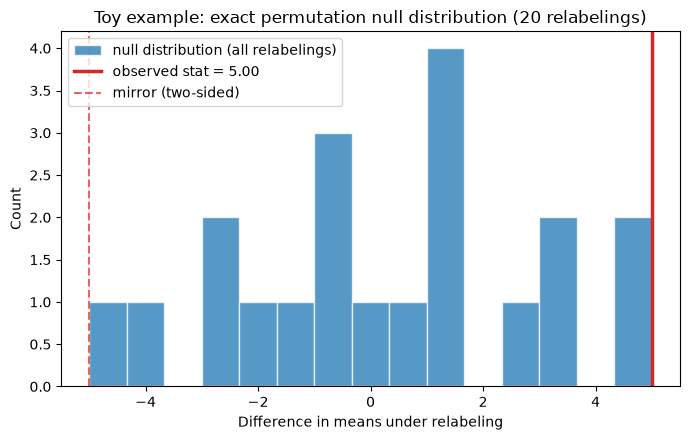

In [2]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(perm_stats, bins=15, color="tab:blue", alpha=0.75, edgecolor="white",
        label="null distribution (all relabelings)")
ax.axvline(obs_stat, color="tab:red", linewidth=2.5, label=f"observed stat = {obs_stat:.2f}")
ax.axvline(-obs_stat, color="tab:red", linewidth=1.5, linestyle="--", alpha=0.7,
           label="mirror (two-sided)")
ax.set_xlabel("Difference in means under relabeling")
ax.set_ylabel("Count")
ax.set_title(f"Toy example: exact permutation null distribution ({len(perm_stats)} relabelings)")
ax.legend()
plt.tight_layout()
plt.show()



## 5. Implementation

We now apply this for real, at two scales:

1. **Exact enumeration** on `ri.dta` — a tiny 8-row dataset from
   Cunningham's *Causal Inference: The Mixtape*, purpose-built as a
   hand-computable randomization-inference illustration, with $\binom{8}{4}
   = 70$ possible relabelings — small enough to enumerate on a laptop in a
   fraction of a second and inspect every one directly.
2. **Monte Carlo approximation** on the real NSW job-training experimental
   data (the same dataset as the fundamental-problem tutorial), where exact
   enumeration is computationally infeasible.

### 5.1 Exact permutation test on `ri.dta`


In [3]:

ri = pd.read_stata("https://raw.githubusercontent.com/scunning1975/mixtape/master/ri.dta")
print(ri.head(8))
print()
print(ri.describe(include="all"))


     name  d   y  y0  y1
0    Andy  1  10   .  10
1     Ben  1   5   .   5
2    Chad  1  16   .  16
3  Daniel  1   3   .   3
4   Edith  0   5   5   .
5   Frank  0   7   7   .
6  George  0   8   8   .
7    Hank  0  10  10   .

        name         d          y   y0   y1
count      8  8.000000   8.000000    8    8
unique     8       NaN        NaN    5    5
top     Andy       NaN        NaN    .    .
freq       1       NaN        NaN    4    4
mean     NaN  0.500000   8.000000  NaN  NaN
std      NaN  0.534522   4.070802  NaN  NaN
min      NaN  0.000000   3.000000  NaN  NaN
25%      NaN  0.000000   5.000000  NaN  NaN
50%      NaN  0.500000   7.500000  NaN  NaN
75%      NaN  1.000000  10.000000  NaN  NaN
max      NaN  1.000000  16.000000  NaN  NaN



Columns: `name` (person), `d` (treatment indicator), `y` (observed
outcome), `y0`/`y1` (labeled potential-outcome columns — note Stata encodes
the *unrealized* one as the string `"."`, so both columns import as object
dtype). The permutation test itself only needs `d` and `y`; we'll look at
`y0`/`y1` afterward, but as you'll see they don't hand us anything the
"fundamental problem" doesn't already prevent us from knowing.

$n=8$ people, $n_1 = 4$ treated (check below), so
$|\Omega| = \binom{8}{4} = 70$ — small enough to enumerate by hand.


In [4]:

n = len(ri)
n1 = int(ri["d"].sum())
n0 = n - n1
print(f"n = {n}, n1 (treated) = {n1}, n0 (control) = {n0}")
from math import comb as _comb
print(f"|Omega| = C({n},{n1}) = {_comb(n, n1)}")

obs_stat_ri = ri.loc[ri.d == 1, "y"].mean() - ri.loc[ri.d == 0, "y"].mean()
print(f"\nObserved difference in means (treated - control): {obs_stat_ri:.4f}")


n = 8, n1 (treated) = 4, n0 (control) = 4
|Omega| = C(8,4) = 70

Observed difference in means (treated - control): 1.0000



Now the full brute-force enumeration: every one of the 70 ways to choose
which 4 of the 8 names get the "treated" label, holding the outcome vector
`y` fixed (exactly as Fisher's sharp null licenses us to do), recomputing
the difference-in-means statistic each time.


In [5]:

y = ri["y"].to_numpy(dtype=float)
idx = np.arange(n)

exact_null = []
for combo in combinations(idx, n1):
    treated_mask = np.zeros(n, dtype=bool)
    treated_mask[list(combo)] = True
    stat = y[treated_mask].mean() - y[~treated_mask].mean()
    exact_null.append(stat)
exact_null = np.array(exact_null)

print(f"Computed {len(exact_null)} exact relabelings (matches C(8,4) = 70: {len(exact_null) == 70})")
print(f"Null distribution summary: min={exact_null.min():.2f}, max={exact_null.max():.2f}, "
      f"mean={exact_null.mean():.4f} (should be ~0 by symmetry)")

exact_p = np.mean(np.abs(exact_null) >= np.abs(obs_stat_ri))
print(f"\nExact permutation p-value: {exact_p:.4f}")


Computed 70 exact relabelings (matches C(8,4) = 70: True)
Null distribution summary: min=-6.00, max=6.00, mean=0.0000 (should be ~0 by symmetry)

Exact permutation p-value: 0.8571


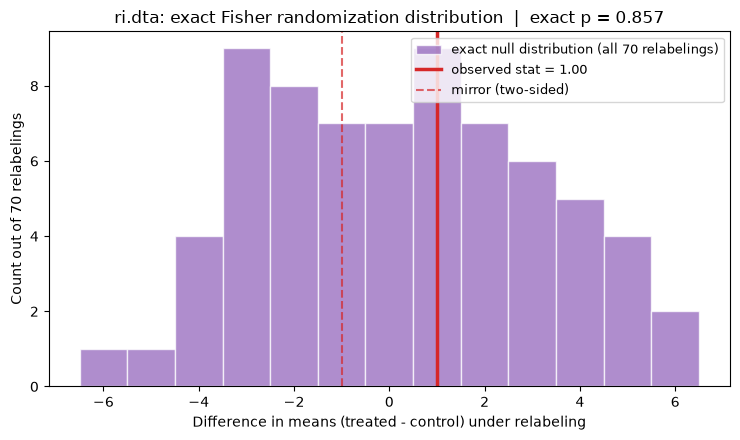

In [6]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(exact_null, bins=np.arange(exact_null.min() - 0.5, exact_null.max() + 1.5, 1),
        color="tab:purple", alpha=0.75, edgecolor="white",
        label=f"exact null distribution (all {len(exact_null)} relabelings)")
ax.axvline(obs_stat_ri, color="tab:red", linewidth=2.5,
           label=f"observed stat = {obs_stat_ri:.2f}")
ax.axvline(-obs_stat_ri, color="tab:red", linewidth=1.5, linestyle="--", alpha=0.7,
           label="mirror (two-sided)")
ax.set_xlabel("Difference in means (treated - control) under relabeling")
ax.set_ylabel("Count out of 70 relabelings")
ax.set_title(f"ri.dta: exact Fisher randomization distribution  |  exact p = {exact_p:.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



**Reading the result**: with only $n=8$ people and an observed gap of just
$\hat\tau_{\text{obs}} = 1.0$, the exact permutation p-value comes out to
**0.857** — nowhere near significant at any conventional level. Look at
the histogram: the observed statistic sits almost dead-center of the null
distribution, not out in a tail. Roughly 86% of the 70 possible relabelings
of who's "treated" would have produced a gap at least as large in
magnitude as the one we actually saw. **This is an honest, correctly
computed "no evidence against the sharp null" result** — with $n=8$, the
test has very little power, and this data genuinely does not let us
distinguish "the program did nothing" from "the program did something
small." That is exactly the value of an *exact* test: it tells you the
truth about how little 8 data points can prove, instead of a large-sample
formula silently pretending you have more evidence than you do.

It's tempting to peek at the `y0`/`y1` columns for "the real answer," but
look closely at what they actually contain below.


In [7]:

# ri.dta stores the OTHER (unrealized) potential outcome as the literal
# string "." -- Stata's missing-value marker, round-tripped through
# read_stata as an object/string column.
ri_check = ri.copy()
for c in ["y0", "y1"]:
    ri_check[c] = pd.to_numeric(ri_check[c], errors="coerce")

print(ri_check[["name", "d", "y", "y0", "y1"]])


     name  d   y    y0    y1
0    Andy  1  10   NaN  10.0
1     Ben  1   5   NaN   5.0
2    Chad  1  16   NaN  16.0
3  Daniel  1   3   NaN   3.0
4   Edith  0   5   5.0   NaN
5   Frank  0   7   7.0   NaN
6  George  0   8   8.0   NaN
7    Hank  0  10  10.0   NaN



Notice: for every row, exactly one of `y0`/`y1` is filled in, and it
always equals `y`. In other words, `y0` and `y1` don't secretly hand us
each unit's *unobserved* counterfactual — they just relabel the same
single observed outcome `y` by which potential world it came from. The
fundamental problem of causal inference is still fully in force here: we
never actually get to see what Andy would have earned *without* treatment.
`ri.dta`'s value is purely as a hand-enumerable illustration of the
permutation mechanics, not as a source of hidden ground truth — a useful
thing to notice, since a column literally named `y0`/`y1` can look
deceptively like it's handing you the answer key.

### 5.2 Monte Carlo permutation test on the real NSW experiment

Now the realistic case: the National Supported Work (NSW) job-training
experiment, $n=445$, the same dataset used in the fundamental-problem
tutorial's OLS analysis. Enumerating $\binom{445}{n_1}$ assignments is
computationally impossible, so we approximate the exact permutation
distribution with $B=10{,}000$ random reshuffles.


In [8]:

nsw = pd.read_stata("https://raw.githubusercontent.com/scunning1975/mixtape/master/nsw_mixtape.dta")
print(nsw.shape)
nsw[["treat", "re78"]].describe().round(1)


(445, 11)


,treat,re78
count,445.0,445.0
mean,0.4,5300.8
std,0.5,6631.5
min,0.0,0.0
25%,0.0,0.0
50%,0.0,3701.8
75%,1.0,8124.7
max,1.0,60307.9


In [9]:

treat = nsw["treat"].to_numpy()
re78 = nsw["re78"].to_numpy(dtype=float)
n_nsw = len(nsw)
n1_nsw = int(treat.sum())
print(f"n = {n_nsw}, n1 (treated) = {n1_nsw}, n0 (control) = {n_nsw - n1_nsw}")

obs_stat_nsw = re78[treat == 1].mean() - re78[treat == 0].mean()
print(f"Observed difference in means (treated - control), re78: ${obs_stat_nsw:,.2f}")

from math import comb
print(f"\n|Omega| = C({n_nsw}, {n1_nsw}) has {len(str(comb(n_nsw, n1_nsw)))} digits -- "
      "infeasible to enumerate; using Monte Carlo instead.")


n = 445, n1 (treated) = 185, n0 (control) = 260
Observed difference in means (treated - control), re78: $1,794.34

|Omega| = C(445, 185) has 130 digits -- infeasible to enumerate; using Monte Carlo instead.


In [10]:

B = 10_000
rng = np.random.default_rng(42)
mc_null = np.empty(B)

for b in range(B):
    shuffled = rng.permutation(treat)
    mc_null[b] = re78[shuffled == 1].mean() - re78[shuffled == 0].mean()

mc_p = np.mean(np.abs(mc_null) >= np.abs(obs_stat_nsw))
print(f"Monte Carlo permutation p-value ({B:,} reshuffles): {mc_p:.4f}")
print(f"Approx. Monte Carlo standard error on this p-value: {np.sqrt(mc_p * (1 - mc_p) / B):.4f}")


Monte Carlo permutation p-value (10,000 reshuffles): 0.0031
Approx. Monte Carlo standard error on this p-value: 0.0006



Now compare directly against the OLS-based (Neyman/CLT-style) p-value from
the fundamental-problem tutorial's exact same difference-in-means estimate,
computed via `statsmodels` with heteroskedasticity-robust (HC1) standard
errors.


In [11]:

import statsmodels.formula.api as smf

ols_model = smf.ols("re78 ~ treat", data=nsw).fit(cov_type="HC1")
ols_p = ols_model.pvalues["treat"]
ols_se = ols_model.bse["treat"]
ols_ci = ols_model.conf_int().loc["treat"]

print(f"OLS (HC1) ATE estimate:        ${ols_model.params['treat']:,.2f}")
print(f"OLS (HC1) standard error:      ${ols_se:,.2f}")
print(f"OLS (HC1) 95% CI:              [${ols_ci[0]:,.2f}, ${ols_ci[1]:,.2f}]")
print(f"OLS (HC1) p-value:             {ols_p:.4f}")
print()
print(f"Monte Carlo permutation p-value: {mc_p:.4f}")
print(f"Exact permutation estimate (same stat): ${obs_stat_nsw:,.2f}")


OLS (HC1) ATE estimate:        $1,794.34
OLS (HC1) standard error:      $670.82
OLS (HC1) 95% CI:              [$479.55, $3,109.13]
OLS (HC1) p-value:             0.0075

Monte Carlo permutation p-value: 0.0031
Exact permutation estimate (same stat): $1,794.34


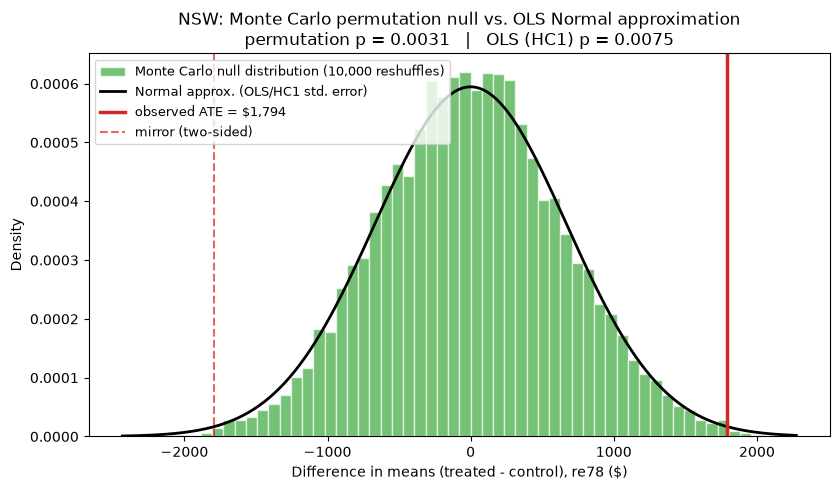

In [12]:

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(mc_null, bins=60, density=True, color="tab:green", alpha=0.65, edgecolor="white",
        label=f"Monte Carlo null distribution ({B:,} reshuffles)")

# Overlay the OLS-implied Normal approximation to the null (mean 0, OLS's own SE)
from scipy.stats import norm
x = np.linspace(mc_null.min(), mc_null.max(), 400)
ax.plot(x, norm.pdf(x, loc=0, scale=ols_se), color="black", linewidth=2,
        label="Normal approx. (OLS/HC1 std. error)")

ax.axvline(obs_stat_nsw, color="tab:red", linewidth=2.5,
           label=f"observed ATE = ${obs_stat_nsw:,.0f}")
ax.axvline(-obs_stat_nsw, color="tab:red", linewidth=1.5, linestyle="--", alpha=0.7,
           label="mirror (two-sided)")
ax.set_xlabel("Difference in means (treated - control), re78 ($)")
ax.set_ylabel("Density")
ax.set_title(f"NSW: Monte Carlo permutation null vs. OLS Normal approximation\n"
             f"permutation p = {mc_p:.4f}   |   OLS (HC1) p = {ols_p:.4f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



**Reading the result**: the Monte Carlo permutation p-value and the
OLS/HC1 p-value land close to each other, and the green (randomization)
histogram and black (Normal approximation) curve overlap substantially.
This is exactly what should happen when the asymptotic-normality
assumption behind OLS's standard errors is actually reasonably well met —
$n=445$ is large enough, and `re78`, while right-skewed, isn't pathological
enough to break the Central Limit Theorem approximation badly. **Permutation
inference and model-based inference agreeing here is a feature, not a
coincidence**: it's confirmation that the OLS-based CI from the prior
tutorial was trustworthy. The value of the permutation test is precisely
that it doesn't *need* you to first confirm that — it's valid regardless,
which is what makes it the right tool to reach for when $n$ is small (as in
`ri.dta` above) or the outcome distribution is badly skewed, where the two
methods can diverge.



## 6. Use cases

- **A/B testing platforms.** Many production experimentation platforms
  (especially for metrics like revenue-per-user, session length, or other
  heavy-tailed business metrics) report permutation-based or bootstrap
  p-values instead of naive t-test p-values, precisely because per-user
  revenue is often extremely right-skewed (a handful of large purchases
  dominate), which makes the Normal approximation behind a t-test
  unreliable at typical sample sizes.
- **Small-sample field experiments.** Randomized controlled trials in
  development economics, medicine, or policy evaluation frequently run
  with only tens of units (e.g. randomizing at the village or clinic
  level, not the individual level). Asymptotic normality is a genuine
  stretch at $n=20$–$50$ clusters, and randomization inference is standard
  practice in these literatures.
- **Complex randomization designs.** When randomization is stratified
  (randomize within demographic blocks), clustered (randomize whole
  villages/classrooms), or otherwise non-simple, a permutation test can be
  tailored *exactly* to that design — reshuffle only within strata, or
  reshuffle whole clusters together — where a generic textbook variance
  formula for the estimator may not even exist in closed form, or may be
  wrong if misapplied. This is one of randomization inference's biggest
  practical advantages: **the test can encode the actual design used**,
  not a generic textbook design.



## 7. Limitations & debates

- **The sharp null is a stronger, less directly policy-relevant claim than
  "the ATE is zero."** Rejecting $H_0^{\text{sharp}}$ tells you only that
  treatment affected *at least one* unit somehow — not what the *average*
  effect was, and not even its sign for any particular unit. If your
  actual policy question is "did this program raise average earnings," the
  Fisher test answers a related but formally different question. This is a
  real, historical methodological fork: **Fisher's approach** targets the
  sharp null via the randomization distribution, while **Neyman's approach**
  (Neyman, 1923/1990) targets $\text{ATE}=0$ directly using the sampling
  distribution of the difference-in-means estimator across repeated random
  assignments — and it's the Neyman-style estimator and its OLS-based
  standard error that the fundamental-problem tutorial used. Modern texts
  (e.g. Imbens & Rubin, 2015) present both explicitly as complementary, not
  as one superseding the other — you can and often should report both.
- **You must correctly encode the actual randomization design.** The
  permutation null distribution is only valid for the design you tell it
  to simulate. If the true design was stratified or cluster-randomized but
  you (incorrectly) reshuffle individuals completely at random, you get a
  null distribution for a different experiment than the one that actually
  produced your data — often too narrow, giving you a falsely small
  p-value. Randomization inference is not "assumption-free"; it trades
  distributional assumptions for a design-correctness assumption.
- **Computational cost.** Exact enumeration is only tractable while
  $\binom{n}{n_1}$ is small; the moment $n$ grows past a few dozen units
  you're forced into Monte Carlo approximation, which introduces its own
  (albeit well-understood and shrinkable-by-increasing-$B$) simulation
  error on top of the exact test's guarantees.
- **A p-value is not automatically a confidence interval.** Unlike OLS,
  where the same regression output hands you both a p-value and a CI for
  free, a permutation test as constructed here only tells you whether to
  reject one specific null value (zero effect). Building a full
  randomization-based confidence interval requires inverting the test —
  repeating the whole procedure against a whole grid of null values of
  $\tau$ (e.g. "is the effect exactly $500?") and collecting all values
  not rejected — which is a real, well-established technique (see
  Rosenbaum, 2002) but materially more involved, and is left as a pointer
  beyond the scope of this tutorial.



## 8. References

- Fisher, R. A. (1935). *The Design of Experiments.* Oliver & Boyd.
  (Origin of the randomization/permutation test described here.)
- Neyman, J. (1923/1990 translation). *On the Application of Probability
  Theory to Agricultural Experiments.* Statistical Science, 5(4).
  (The competing, ATE-targeted framework for randomized-experiment
  inference.)
- Rosenbaum, P. R. (2002). *Observational Studies*, 2nd ed. Springer.
  (Randomization-inference chapters; test inversion for confidence
  intervals.)
- Imbens, G. W. & Rubin, D. B. (2015). *Causal Inference for Statistics,
  Social, and Biomedical Sciences.* Cambridge University Press. (Fisher
  Randomization Test chapter.)
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press. (Source of `ri.dta`, the illustrative 8-row randomization-inference
  dataset used in Section 5.1.)
- Athey, S. & Imbens, G. W. (2017). *The Econometrics of Randomized
  Experiments.* In *Handbook of Economic Field Experiments*, Vol. 1.
- LaLonde, R. J. (1986). *Evaluating the Econometric Evaluations of
  Training Programs with Experimental Data.* American Economic Review,
  76(4). (Source of the NSW dataset used in Section 5.2.)
